
# Lightweight Transformer Baseline — Incident Classification 

Task: classify `NORMAL`, `ACCIDENT`, and `OTHER_DISRUPTION` using the same frozen dataset and split manifests as the other Task 2 baselines.

Input sequence:
- 7 hourly steps: t-3, t-2, t-1, t0, t+1, t+2, t+3
- 2 channels per step: log1p(flow) and first difference of log1p(flow)

Architecture:
- input projection
- learnable positional embedding
- one Transformer encoder block
- multi-head self-attention
- residual connections + layer normalization
- feed-forward network
- global average pooling
- softmax classification head

Early stopping monitors validation loss and restores the best weights. Model configuration is selected by validation Macro-F1. The test set is used only for final evaluation.


In [2]:

# Run only if TensorFlow is not installed:
# !pip install -U tensorflow

from pathlib import Path
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_INT = {label: i for i, label in enumerate(CLASS_ORDER)}
INT_TO_CLASS = {i: label for label, i in CLASS_TO_INT.items()}

DATA_DIR = Path(".")
CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")

OUTPUT_DIR = DATA_DIR / "lightweight_transformer_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files or update DATA_DIR."
        )

print("TensorFlow version:", tf.__version__)
print("Output directory:", OUTPUT_DIR.resolve())


TensorFlow version: 2.19.0
Output directory: /Users/andishahifahmuthahharah/Downloads/lightweight_transformer_outputs


## 1. Load and validate data

In [3]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

assert canonical["event_sample_id"].is_unique
assert grouped_manifest["event_sample_id"].is_unique
assert spatial_manifest["event_sample_id"].is_unique

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"])
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"])
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179


## 2. Prepare 7-hour sequence

In [4]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

def merge_split(canonical_df, manifest):
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df)
    assert (merged["target_class"] == merged["target_class_manifest"]).all()

    return merged.drop(columns="target_class_manifest")

def encode_target(y):
    encoded = y.map(CLASS_TO_INT)
    if encoded.isna().any():
        raise ValueError("Unknown target class found.")
    return encoded.astype(int).to_numpy()

def decode_target(y_int):
    return np.array([INT_TO_CLASS[int(v)] for v in y_int])

def prepare_sequence_data(data):
    flow = data[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    log_flow = np.log1p(flow)
    diff = np.diff(log_flow, axis=1, prepend=log_flow[:, [0]])

    X = np.stack([log_flow, diff], axis=-1).astype(np.float32)
    y = encode_target(data["target_class"])

    return X, y

def metric_row(y_true_label, y_pred_label):
    return {
        "accuracy": accuracy_score(y_true_label, y_pred_label),
        "balanced_accuracy": balanced_accuracy_score(y_true_label, y_pred_label),
        "macro_f1": f1_score(y_true_label, y_pred_label, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true_label, y_pred_label, average="weighted", zero_division=0),
    }


## 3. Lightweight Transformer model

In [5]:

MODEL_CONFIGS = [
    {
        "d_model": 32,
        "num_heads": 2,
        "ff_dim": 64,
        "dropout": 0.20,
        "learning_rate": 1e-3,
        "l2_strength": 1e-4,
    },
    {
        "d_model": 48,
        "num_heads": 4,
        "ff_dim": 96,
        "dropout": 0.30,
        "learning_rate": 5e-4,
        "l2_strength": 1e-4,
    },
    {
        "d_model": 32,
        "num_heads": 4,
        "ff_dim": 64,
        "dropout": 0.40,
        "learning_rate": 5e-4,
        "l2_strength": 1e-3,
    },
]

MAX_EPOCHS = 300
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 25
REDUCE_LR_PATIENCE = 10


In [6]:

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model,
        )

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        positions = tf.range(seq_len)
        return inputs + self.position_embedding(positions)

def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout, l2_strength):
    regularizer = tf.keras.regularizers.l2(l2_strength)

    norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout,
        kernel_regularizer=regularizer,
    )(norm1, norm1)

    attn = tf.keras.layers.Dropout(dropout)(attn)
    x = tf.keras.layers.Add()([x, attn])

    norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    ff = tf.keras.layers.Dense(
        ff_dim,
        activation="gelu",
        kernel_regularizer=regularizer,
    )(norm2)
    ff = tf.keras.layers.Dropout(dropout)(ff)
    ff = tf.keras.layers.Dense(
        d_model,
        kernel_regularizer=regularizer,
    )(ff)
    ff = tf.keras.layers.Dropout(dropout)(ff)

    return tf.keras.layers.Add()([x, ff])

def build_transformer_model(input_shape, config):
    sequence_length = input_shape[0]
    regularizer = tf.keras.regularizers.l2(config["l2_strength"])

    inputs = tf.keras.Input(shape=input_shape, name="traffic_sequence")

    x = tf.keras.layers.Dense(
        config["d_model"],
        kernel_regularizer=regularizer,
        name="input_projection",
    )(inputs)

    x = PositionalEmbedding(
        sequence_length=sequence_length,
        d_model=config["d_model"],
        name="positional_embedding",
    )(x)

    x = tf.keras.layers.Dropout(config["dropout"])(x)

    x = transformer_encoder_block(
        x,
        d_model=config["d_model"],
        num_heads=config["num_heads"],
        ff_dim=config["ff_dim"],
        dropout=config["dropout"],
        l2_strength=config["l2_strength"],
    )

    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    x = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizer,
    )(x)

    x = tf.keras.layers.Dropout(config["dropout"])(x)

    outputs = tf.keras.layers.Dense(
        len(CLASS_ORDER),
        activation="softmax",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="lightweight_transformer")

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config["learning_rate"],
        weight_decay=1e-4,
        clipnorm=1.0,
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


## 4. Train, early stop, and evaluate

In [7]:

def run_transformer_experiment(split_name, manifest):
    tf.keras.backend.clear_session()

    data = merge_split(canonical, manifest)
    X, y = prepare_sequence_data(data)
    y_label = data["target_class"].astype(str)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train_raw = X[masks["train"]]
    X_val_raw = X[masks["validation"]]
    X_test_raw = X[masks["test"]]

    y_train = y[masks["train"]]
    y_val = y[masks["validation"]]
    y_test = y[masks["test"]]

    y_train_label = y_label.loc[masks["train"]]
    y_val_label = y_label.loc[masks["validation"]]
    y_test_label = y_label.loc[masks["test"]]

    # Scale channels using training data only
    scaler = StandardScaler()
    scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

    def scale_3d(arr):
        shape = arr.shape
        return scaler.transform(arr.reshape(-1, shape[-1])).reshape(shape).astype(np.float32)

    X_train = scale_3d(X_train_raw)
    X_val = scale_3d(X_val_raw)
    X_test = scale_3d(X_test_raw)

    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(CLASS_ORDER)),
        y=y_train,
    )
    class_weight = {i: float(w) for i, w in enumerate(class_weights_values)}

    print(f"\n=== {split_name} ===")
    print("Train / validation / test:", len(y_train), len(y_val), len(y_test))
    print("Class weights:", class_weight)

    split_counts = (
        data.groupby(["split", "target_class"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=["train", "validation", "test"],
            columns=CLASS_ORDER,
            fill_value=0,
        )
    )
    display(split_counts)

    search_rows = []
    models = []
    histories = []

    for i, config in enumerate(MODEL_CONFIGS, start=1):
        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_STATE + i)

        model = build_transformer_model(X_train.shape[1:], config)

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=REDUCE_LR_PATIENCE,
                min_lr=1e-6,
            ),
            tf.keras.callbacks.TerminateOnNaN(),
        ]

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
            shuffle=True,
        )

        val_prob = model.predict(X_val, verbose=0)
        val_pred = np.argmax(val_prob, axis=1)
        val_pred_label = decode_target(val_pred)

        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        best_val_loss = float(np.min(history.history["val_loss"]))

        row = {
            **config,
            "epochs_trained": len(history.history["loss"]),
            "best_epoch": best_epoch,
            "best_validation_loss": best_val_loss,
            **metric_row(y_val_label, val_pred_label),
        }

        search_rows.append(row)
        models.append(model)
        histories.append(history.history)

        print(
            f"{i:02d}/{len(MODEL_CONFIGS)} | "
            f"epochs={row['epochs_trained']:3d} | "
            f"best_epoch={best_epoch:3d} | "
            f"val_macro_f1={row['macro_f1']:.4f} | "
            f"val_loss={best_val_loss:.4f}"
        )

    search_df = pd.DataFrame(search_rows)

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "best_validation_loss"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_history = histories[best_idx]
    best_config = MODEL_CONFIGS[best_idx]

    print("\nBest validation configuration:")
    print(best_config)
    display(ranking)

    partition_results = []
    prediction_frames = []

    for part, X_part, y_part_label in [
        ("train", X_train, y_train_label),
        ("validation", X_val, y_val_label),
        ("test", X_test, y_test_label),
    ]:
        prob = best_model.predict(X_part, verbose=0)
        pred_int = np.argmax(prob, axis=1)
        pred_label = decode_target(pred_int)

        partition_results.append({
            "split_scheme": split_name,
            "partition": part,
            "best_epoch": int(search_df.loc[best_idx, "best_epoch"]),
            **metric_row(y_part_label, pred_label),
        })

        ids = data.loc[masks[part], "event_sample_id"].to_numpy()

        frame = pd.DataFrame({
            "event_sample_id": ids,
            "split_scheme": split_name,
            "partition": part,
            "y_true": y_part_label.to_numpy(),
            "y_pred": pred_label,
        })

        for class_idx, class_name in enumerate(CLASS_ORDER):
            frame[f"prob_{class_name}"] = prob[:, class_idx]

        prediction_frames.append(frame)

    results_df = pd.DataFrame(partition_results)
    prediction_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = prediction_df.loc[
        prediction_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    print("\nOverall metrics:")
    display(results_df)

    print("\nTest classification report:")
    report_df = pd.DataFrame(
        classification_report(
            y_test_label,
            test_pred,
            labels=CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T
    display(report_df)

    safe_name = split_name.lower().replace("-", "_").replace(" ", "_")

    search_df.to_csv(OUTPUT_DIR / f"{safe_name}_configuration_search.csv", index=False)
    results_df.to_csv(OUTPUT_DIR / f"{safe_name}_metrics.csv", index=False)
    prediction_df.to_csv(OUTPUT_DIR / f"{safe_name}_predictions.csv", index=False)
    report_df.to_csv(OUTPUT_DIR / f"{safe_name}_test_classification_report.csv")

    best_metadata = {
        **best_config,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "epochs_trained": int(search_df.loc[best_idx, "epochs_trained"]),
        "best_epoch": int(search_df.loc[best_idx, "best_epoch"]),
        "best_validation_loss": float(search_df.loc[best_idx, "best_validation_loss"]),
    }

    with open(OUTPUT_DIR / f"{safe_name}_best_config.json", "w") as f:
        json.dump(best_metadata, f, indent=2)

    best_model.save(OUTPUT_DIR / f"{safe_name}_lightweight_transformer.keras")

    np.savez(
        OUTPUT_DIR / f"{safe_name}_scaler.npz",
        mean=scaler.mean_,
        scale=scaler.scale_,
    )

    history_df = pd.DataFrame(best_history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df.to_csv(OUTPUT_DIR / f"{safe_name}_training_history.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df["epoch"], history_df["loss"], label="Training loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    ax.axvline(
        best_metadata["best_epoch"],
        linestyle="--",
        label=f"Best epoch = {best_metadata['best_epoch']}",
    )
    ax.set_title(f"Lightweight Transformer — {split_name} early stopping")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_label,
        test_pred,
        labels=CLASS_ORDER,
        display_labels=CLASS_ORDER,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Lightweight Transformer — {split_name} test confusion matrix")
    fig.tight_layout()
    plt.show()

    return {
        "model": best_model,
        "best_config": best_metadata,
        "metrics": results_df,
        "report": report_df,
        "predictions": prediction_df,
        "search": search_df,
        "history": history_df,
    }


## 5. Grouped-random experiment


=== Grouped-random ===
Train / validation / test: 3685 784 796
Class weights: {0: 0.4893758300132802, 1: 3.4895833333333335, 2: 1.4925070878898339}


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181


01/3 | epochs= 57 | best_epoch= 32 | val_macro_f1=0.2812 | val_loss=1.0970
02/3 | epochs= 31 | best_epoch=  6 | val_macro_f1=0.2974 | val_loss=1.1038
03/3 | epochs=126 | best_epoch=101 | val_macro_f1=0.2805 | val_loss=1.0970

Best validation configuration:
{'d_model': 48, 'num_heads': 4, 'ff_dim': 96, 'dropout': 0.3, 'learning_rate': 0.0005, 'l2_strength': 0.0001}


,d_model,num_heads,ff_dim,dropout,learning_rate,l2_strength,epochs_trained,best_epoch,best_validation_loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
1,48,4,96,0.3,0.0005,0.0001,31,6,1.103833,0.391582,0.307614,0.297398,0.431936
0,32,2,64,0.2,0.0010,0.0001,57,32,1.097034,0.332908,0.315536,0.281229,0.369406
2,32,4,64,0.4,0.0005,0.0010,126,101,1.096959,0.329082,0.336523,0.280461,0.346398



Overall metrics:


,split_scheme,partition,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,train,6,0.383446,0.354001,0.318302,0.424178
1,Grouped-random,validation,6,0.391582,0.307614,0.297398,0.431936
2,Grouped-random,test,6,0.404523,0.361313,0.330475,0.444117



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.697531,0.417745,0.522543,541.000000
ACCIDENT,0.091892,0.229730,0.131274,74.000000
OTHER_DISRUPTION,0.275261,0.436464,0.337607,181.000000
accuracy,0.404523,0.404523,0.404523,0.404523
macro avg,0.354895,0.361313,0.330475,796.000000
weighted avg,0.545209,0.404523,0.444117,796.000000


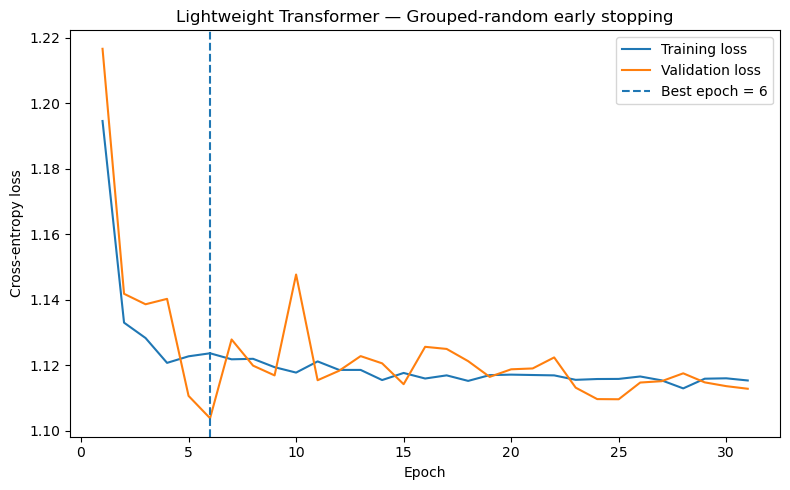

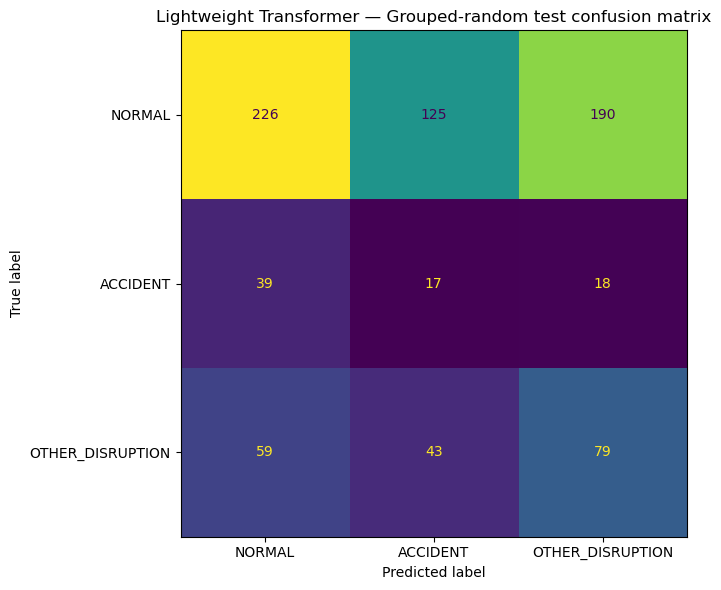

In [8]:

grouped_results = run_transformer_experiment(
    split_name="Grouped-random",
    manifest=grouped_manifest,
)


## 6. Spatial holdout experiment


=== Spatial holdout ===
Train / validation / test: 3685 784 796
Class weights: {0: 0.4893758300132802, 1: 3.4895833333333335, 2: 1.4925070878898339}


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181


01/3 | epochs= 44 | best_epoch= 19 | val_macro_f1=0.2301 | val_loss=1.1039
02/3 | epochs= 28 | best_epoch=  3 | val_macro_f1=0.3115 | val_loss=1.0922
03/3 | epochs=187 | best_epoch=162 | val_macro_f1=0.2318 | val_loss=1.1314

Best validation configuration:
{'d_model': 48, 'num_heads': 4, 'ff_dim': 96, 'dropout': 0.3, 'learning_rate': 0.0005, 'l2_strength': 0.0001}


,d_model,num_heads,ff_dim,dropout,learning_rate,l2_strength,epochs_trained,best_epoch,best_validation_loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
1,48,4,96,0.3,0.0005,0.0001,28,3,1.092183,0.405612,0.327528,0.311548,0.438670
2,32,4,64,0.4,0.0005,0.0010,187,162,1.131402,0.239796,0.318615,0.231814,0.258840
0,32,2,64,0.2,0.0010,0.0001,44,19,1.103866,0.235969,0.319845,0.230132,0.256509



Overall metrics:


,split_scheme,partition,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Spatial holdout,train,3,0.408412,0.364358,0.332746,0.444326
1,Spatial holdout,validation,3,0.405612,0.327528,0.311548,0.438670
2,Spatial holdout,test,3,0.417085,0.352934,0.327651,0.448848



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.688953,0.438078,0.535593,541.000000
ACCIDENT,0.102564,0.162162,0.125654,74.000000
OTHER_DISRUPTION,0.247761,0.458564,0.321705,181.000000
accuracy,0.417085,0.417085,0.417085,0.417085
macro avg,0.346426,0.352934,0.327651,796.000000
weighted avg,0.534119,0.417085,0.448848,796.000000


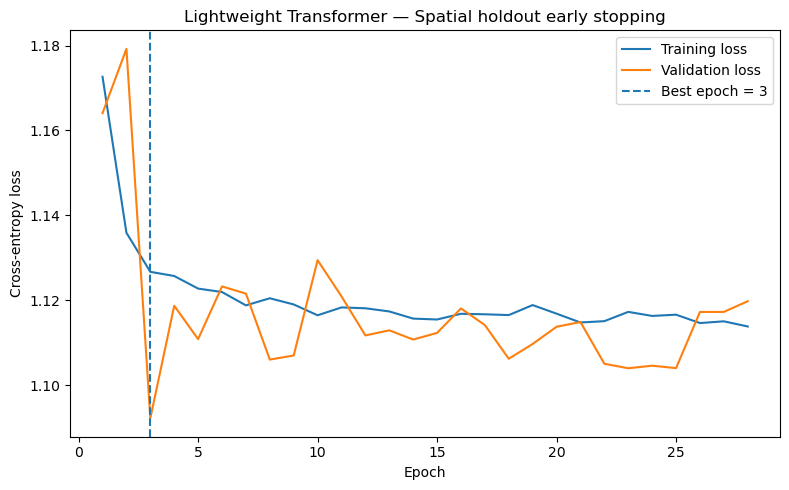

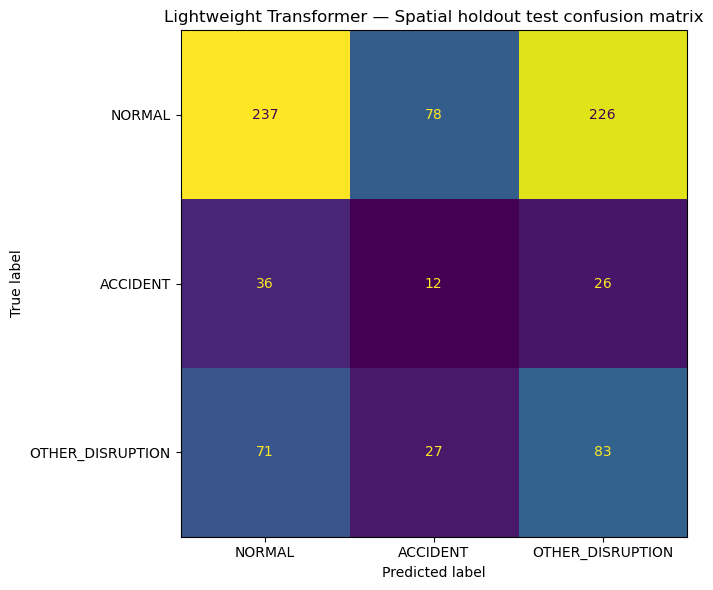

In [9]:

spatial_results = run_transformer_experiment(
    split_name="Spatial holdout",
    manifest=spatial_manifest,
)


## 7. Final comparison

In [10]:

comparison = pd.concat(
    [grouped_results["metrics"], spatial_results["metrics"]],
    ignore_index=True,
)

comparison.to_csv(
    OUTPUT_DIR / "lightweight_transformer_all_metrics.csv",
    index=False,
)

test_comparison = comparison[
    comparison["partition"].eq("test")
].reset_index(drop=True)

print("Lightweight Transformer test-set comparison:")
display(test_comparison)

print("\nReference baselines:")
print("Decision Tree grouped/spatial Macro-F1: 0.303 / 0.253")
print("Random Forest grouped/spatial Macro-F1: 0.352 / 0.313")
print("XGBoost grouped/spatial Macro-F1: 0.336 / 0.287")
print("LSTM grouped/spatial Macro-F1: 0.322 / 0.332")


Lightweight Transformer test-set comparison:


,split_scheme,partition,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,test,6,0.404523,0.361313,0.330475,0.444117
1,Spatial holdout,test,3,0.417085,0.352934,0.327651,0.448848



Reference baselines:
Decision Tree grouped/spatial Macro-F1: 0.303 / 0.253
Random Forest grouped/spatial Macro-F1: 0.352 / 0.313
XGBoost grouped/spatial Macro-F1: 0.336 / 0.287
LSTM grouped/spatial Macro-F1: 0.322 / 0.332
